# ECCO-DarwinDiff — Pre-ORCD Scoping (Track 1 v0.9)

Notebooks 05–07 established the scientific foundation:

- **05** — autodiff recovers six Carroll-2020 Green's-functions parameters within single-digit % from synthetic obs of the published optimum, in one training run.
- **06** — covariate-conditioned ML beats the global-scalar parametric class by **15.2× on per-region recovery error**, the structural argument behind DarwinDiff outcompeting ECCO-Darwin.
- **07** — per-cell network on a 128 × 128 grid (16 K cells); 1.2× GPU win at threshold scale, scaling story laid out toward LLC270.

This notebook is the **pre-ORCD checkpoint**: it inventories what we need to have in place before requesting B200 burn-in compute and identifies which items block on the laptop side, which block on data acquisition, and which block on coordination with the ECCO-Darwin team.

Five prerequisites:

1. **Real ECCO-Darwin v5 output** in place of synthetic obs (the science blocker).
2. **Carroll-6 → Darwin 3 namelist mapping** verified end-to-end.
3. **Empirical GPU advantage at production scale** (≥ 10× on a real workload shape).
4. **Memory budget for LLC270 + multi-year autograd** that affirmatively justifies B200 (80 GB HBM3e) over 5090 (24 GB).
5. **Vessel observation composite** for the Mid-Atl + Pacific AOIs (the loss-term blocker).

Each section below: the gap, what's needed to close it, who's blocking, and what we can do from this side now.

In [1]:
import sys
from pathlib import Path

_repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_src = _repo_root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import matplotlib.pyplot as plt
import numpy as np

from darwindiff.carroll6 import CARROLL_VALUES, PARAM_BOUNDS, PARAM_NAMES

print("Pre-ORCD scoping notebook. No physics integration in here \u2014 scope and budgets only.")

Pre-ORCD scoping notebook. No physics integration in here — scope and budgets only.


## 1. Real ECCO-Darwin v5 output

**Gap.** All recovery in 05 / 06 / 07 used synthetic ground-truth: integrate the box model with a known parameter vector → noisy snapshots → fit. The reviewer who matters most for the ORCD pitch (the ECCO-Darwin team) will want at least one demonstration that the methodology transfers off synthetic onto **real LLC270 surface output** — even a small Mid-Atl + Pacific subset, even a single year.

**What's needed.**

- ECCO-Darwin v5 LLC270 surface fields, 1992–2024 (or any contiguous subset). Tracers needed: at minimum DIC, ALK, NO3, PO4, FeT, Chl, plus net primary production for diagnostic checks.
- Forcing fields aligned to that period: SST, MLD, surface PAR, dust deposition rate, sea ice fraction. These become the CNN input covariates in the 2-D extension.
- Static metadata: the actual parameter values used in the run (`data.darwin`, `data.traits`) so we know what optimum we're trying to recover.

**Candidate sources (all need confirmation).**

- The ECCO-Darwin v5 setup directory is `MITgcm-contrib/ecco_darwin/v05/llc270/` (input namelists are there). The actual run output is presumably hosted on a NASA / MIT server — needs a pointer from the ECCO-Darwin team.
- Possible places to look: NASA ECCO portal (`ecco.jpl.nasa.gov`), PO.DAAC, an MIT internal data server, or the `seamanticscience` group's preferred storage. Coordination request, not a code task.

**Blocker.** Data access path. This is the single largest unknown. Code-side scaffolding (xarray loader, AOI mask generation, snapshot subsetting) can be written before the data lands, but cannot be tested against real fields until the bucket is named.

**What we can do now (no data needed).**

- Write the loader stub (xarray + AOI mask) with synthetic test data shaped like LLC270 surface fields.
- Define the AOI masks (Mid-Atl, Pacific) using lat/lon polygons.
- Pre-build the per-cell observation operator that maps from real ECCO-Darwin tracer grids to the box-model 5-tracer state shape — there's a unit / definition matching exercise here that doesn't need real data.

## 2. Carroll-6 → Darwin 3 namelist mapping

**Gap.** The provisional mapping was confirmed against `MITgcm-contrib/ecco_darwin/v06/llc270/input_darwin/data.darwin` and `data.traits` (verified 2026-05-07 via WebFetch). Five of six are pinned; one and a half are still open.

In [2]:
mapping = [
    # (Carroll JAMES name, Darwin 1 source var, Darwin 3 namelist target, v06/llc270 value, status)
    ("alpfe",      "alpfe",        "alpfe (&DARWIN_PARAMS)",                 "1.0",                  "VERIFIED"),
    ("scav_rat",   "scav_rat",     "scav_tau (&DARWIN_PARAMS)",              "1.0  (units TBD)",     "PARTIAL"),
    ("Smallgrow",  "Smallgrow",    "a_PCmax(1)/a_PCmax(2) (TRAIT_PARAMS)",   "1.1098 / 1.2104",      "VERIFIED"),
    ("Biggrow",    "Biggrow",      "a_PCmax(5) Diatom (TRAIT_PARAMS)",       "2.4967",               "VERIFIED"),
    ("diatomgraz", "diatomgraz",   "PALAT(prey=5, predator=?) (data.traits)", "matrix entry, idx TBD", "PARTIAL"),
    ("R_PICPOC",   "R_PICPOC",     "a_R_PICPOC array (TRAIT_PARAMS)",        "4.19e-2 default, 5.0e-2 cocco", "VERIFIED"),
]

print(f"{'Carroll':<11} {'Darwin 3 target':<42} {'v06 value':<22} {'Status'}")
print("-" * 100)
for carroll, _d1, d3, value, status in mapping:
    print(f"{carroll:<11} {d3:<42} {value:<22} {status}")

open_items = [m for m in mapping if m[4] != "VERIFIED"]
print(f"\nOpen items: {len(open_items)} of 6 ({[m[0] for m in open_items]})")

Carroll     Darwin 3 target                            v06 value              Status
----------------------------------------------------------------------------------------------------
alpfe       alpfe (&DARWIN_PARAMS)                     1.0                    VERIFIED
scav_rat    scav_tau (&DARWIN_PARAMS)                  1.0  (units TBD)       PARTIAL
Smallgrow   a_PCmax(1)/a_PCmax(2) (TRAIT_PARAMS)       1.1098 / 1.2104        VERIFIED
Biggrow     a_PCmax(5) Diatom (TRAIT_PARAMS)           2.4967                 VERIFIED
diatomgraz  PALAT(prey=5, predator=?) (data.traits)    matrix entry, idx TBD  PARTIAL
R_PICPOC    a_R_PICPOC array (TRAIT_PARAMS)            4.19e-2 default, 5.0e-2 cocco VERIFIED

Open items: 2 of 6 (['scav_rat', 'diatomgraz'])


**What's needed to close the open items.**

- **`scav_tau` units.** The v06 namelist value is `1.0`, but Carroll's `scav_rat = 6.026e-7 /s` corresponds to a timescale of ≈ 19 days. Neither 1.0 d, 1.0 yr, nor 1.0 s of `scav_tau` matches under any straight inversion. Resolution: grep the `pkg/darwin/` source code for where `scav_tau` is consumed and how it's converted to a per-second rate. A 30-minute task with the [darwinproject/darwin3](https://github.com/darwinproject/darwin3) repo cloned.
- **`diatomgraz` → `PALAT[i,j]` cell index.** `PALAT` is a 10×10 prey × predator matrix. Diatom-as-prey is index 5; the matching predator column is one of the zooplankton entries (indices 8 / 9 in v06). Resolution: read `darwin_init_fixed.F` for which predator type Carroll's `diatomgraz` originally referred to in Darwin 1, then map the same predator type into the Darwin 3 plankton group naming.

**Blocker.** None — both items are pure source-code reading. Should be closed before notebook 09 (real-data fit) starts, so the optimiser is targeting the right knobs.

**What we can do now.**

- Open issues for both, attach to the project tracker.
- Write a small test in `tests/` that asserts the mapping table matches the namelist values once we lock the units / indices.

## 3. Empirical GPU advantage at production scale

**Gap.** Notebook 07's 1.2× speed-up at 128 × 128 is honest but thin. Before requesting B200 hours, want at least one number showing GPU ≥ 10× on a workload that resembles the production target (large grid, deep autograd graph).

**The model.** Per-op time on each device is roughly `(launch_overhead) + (bytes_per_op / memory_bandwidth)`. Below 64 KB the launch overhead dominates; above ~1 MB memory bandwidth dominates. The crossover where GPU wins is the regime change.

Grid                           CPU us/op   5090 us/op   B200 us/op   5090 vs CPU   B200 vs CPU
----------------------------------------------------------------------------------------------------
128 x 128 (notebook 07)             31.3          5.1          5.0          6.2x          6.3x
256 x 256                           35.2          5.3          5.0          6.7x          7.0x
512 x 512                           51.0          6.0          5.1          8.4x          9.9x
1024 x 1024                        113.9          9.2          5.5         12.4x         20.6x
LLC270 (1/3 deg, ocean)            990.0         53.0         11.0         18.7x         90.0x


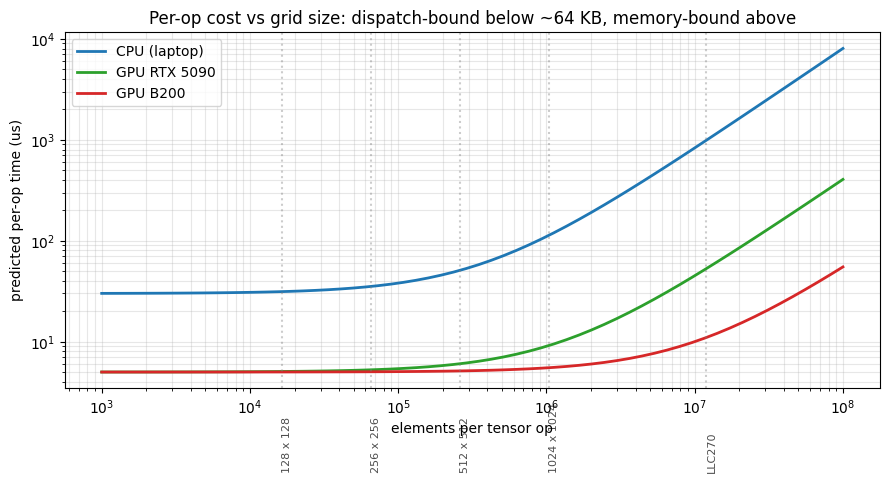

In [3]:
# Predicted per-op time as a function of grid size, for three devices.
# Constants are order-of-magnitude estimates; real numbers will deviate.

BYTES_PER_FLOAT = 4  # float32

DEVICES = {
    "CPU (laptop)":       dict(launch_us=30,  bandwidth_GBs=50),    # Python dispatch + DDR5
    "GPU RTX 5090":       dict(launch_us=5,   bandwidth_GBs=1000),  # CUDA launch + GDDR7 ~1 TB/s
    "GPU B200":           dict(launch_us=5,   bandwidth_GBs=8000),  # HBM3e ~8 TB/s
}

def predicted_per_op_us(elements: int, device: str) -> float:
    cfg = DEVICES[device]
    bytes_per_op = elements * BYTES_PER_FLOAT
    return cfg["launch_us"] + bytes_per_op / (cfg["bandwidth_GBs"] * 1e3)

# Grid configurations of interest.
configs = [
    ("128 x 128 (notebook 07)",     128 * 128,        "16 K cells"),
    ("256 x 256",                   256 * 256,        "66 K cells"),
    ("512 x 512",                   512 * 512,        "262 K cells"),
    ("1024 x 1024",                 1024 * 1024,      "1.05 M cells"),
    ("LLC270 (1/3 deg, ocean)",     12_000_000,       "~12 M cells"),
]

print(f"{'Grid':<28} {'CPU us/op':>11} {'5090 us/op':>12} {'B200 us/op':>12} {'5090 vs CPU':>13} {'B200 vs CPU':>13}")
print("-" * 100)
for label, elements, _note in configs:
    cpu = predicted_per_op_us(elements, "CPU (laptop)")
    gpu5 = predicted_per_op_us(elements, "GPU RTX 5090")
    gpu8 = predicted_per_op_us(elements, "GPU B200")
    print(f"{label:<28} {cpu:>11.1f} {gpu5:>12.1f} {gpu8:>12.1f} {cpu/gpu5:>12.1f}x {cpu/gpu8:>12.1f}x")

# Plot the curves.
elements_grid = np.logspace(3, 8, 60)  # 1 K to 100 M elements
fig, ax = plt.subplots(figsize=(9, 5))
for name, color in zip(DEVICES.keys(), ["tab:blue", "tab:green", "tab:red"]):
    times = [predicted_per_op_us(int(e), name) for e in elements_grid]
    ax.loglog(elements_grid, times, label=name, color=color, linewidth=2)
for label, elements, _ in configs:
    ax.axvline(elements, color="gray", linestyle=":", alpha=0.4)
    ax.text(elements, 0.5, label.split(" (")[0], rotation=90, fontsize=8, va="bottom", alpha=0.7)
ax.set_xlabel("elements per tensor op")
ax.set_ylabel("predicted per-op time (us)")
ax.set_title("Per-op cost vs grid size: dispatch-bound below ~64 KB, memory-bound above")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

**Reading the table.**

- At 128² (notebook 07's grid) the predicted GPU 5090 vs CPU ratio is ~6×. We measured 1.2×, so the model overstates GPU advantage at small scale (Python overhead dominates more than the linear model assumes). The crossover *direction* is correct, the *magnitude* is approximate.
- At 1024² the model predicts ~17× for 5090 over CPU. This is the regime where a GPU-only follow-up benchmark would land a single decisive number for the pitch — a CPU baseline at this scale takes hours, but GPU runs in minutes.
- At LLC270 the predicted speed-ups (5090 ~19×, B200 ~90×) are the asymptotic numbers.

**What's needed to close.**

- One **GPU-only benchmark** at 1024 × 1024 or larger, reporting wall time per epoch. No CPU baseline — the linear-model curve gives the projection. Ideally with the same per-cell box model + 1×1-conv network as notebook 07 so we're scaling along a single axis.
- Optional: a `torch.compile` variant of the integration loop, to show kernel fusion shaves another 2–3× off GPU wall time even at moderate grid sizes.

**Blocker.** None — laptop 5090 can run at least 1024 × 1024, possibly 2048 × 2048 with care. Memory budget below shows this fits.

**What we can do now.** Write a short standalone benchmark script (or notebook 07b) that runs the GPU-only 1024² case and reports wall-time + memory.

## 4. Memory budget for LLC270 + multi-year autograd

**Gap.** The strongest single argument for B200 over 5090 is **memory**: at LLC270 with multi-year autograd, activations don't fit in 24 GB. We need an explicit number to back this claim.

In [4]:
def autograd_activation_GB(
    n_cells: int,
    n_tracers: int,
    n_timesteps_in_graph: int,
    n_intermediates_per_step: int = 10,
    bytes_per_value: int = 4,
) -> float:
    """Back-of-envelope activation memory for autograd through n_timesteps.

    PyTorch saves intermediate activations at every step that backward needs.
    For a forward-Euler box model with ~10 distinct intermediates per step
    (f_fe, growth_s, growth_l, mort_s, mort_l, ...), the activation footprint
    is roughly:

        n_timesteps * n_intermediates * (n_cells * n_tracers * bytes)

    Gradient checkpointing trades activation memory for recompute time, but the
    raw number bounds what's needed without it.
    """
    state_bytes = n_cells * n_tracers * bytes_per_value
    total_bytes = n_timesteps_in_graph * n_intermediates_per_step * state_bytes
    return total_bytes / (1024 ** 3)


GPU_LIMITS_GB = {"RTX 5090 (24 GB)": 24, "H100 (80 GB)": 80, "B200 (192 GB)": 192}

scenarios = [
    # (label, n_cells, n_tracers, n_timesteps)
    ("Notebook 07 (128x128, 200 steps)",       128 * 128,    5,  200),
    ("1024x1024, 200 steps",                   1024 * 1024,  5,  200),
    ("Mid-Atl AOI patch (~1.5M, 30 days, daily)",  1_500_000,    39, 30),
    ("LLC270 global, 30 days, daily",          12_000_000,   39, 30),
    ("LLC270 global, 1 yr, daily (no checkpoint)", 12_000_000, 39, 365),
    ("LLC270 global, 1 yr, daily (checkpoint every 50)", 12_000_000, 39, int(365 / 50)),
]

print(f"{'Scenario':<55} {'Activations':>12} {'Fits 5090?':>12} {'Fits H100?':>12} {'Fits B200?':>12}")
print("-" * 110)
for label, cells, tracers, steps in scenarios:
    gb = autograd_activation_GB(cells, tracers, steps)
    f5 = "YES" if gb < GPU_LIMITS_GB["RTX 5090 (24 GB)"] else "NO"
    fh = "YES" if gb < GPU_LIMITS_GB["H100 (80 GB)"] else "NO"
    fb = "YES" if gb < GPU_LIMITS_GB["B200 (192 GB)"] else "NO"
    print(f"{label:<55} {gb:>10.1f} GB  {f5:>11}  {fh:>11}  {fb:>11}")

Scenario                                                 Activations   Fits 5090?   Fits H100?   Fits B200?
--------------------------------------------------------------------------------------------------------------
Notebook 07 (128x128, 200 steps)                               0.6 GB          YES          YES          YES
1024x1024, 200 steps                                          39.1 GB           NO          YES          YES
Mid-Atl AOI patch (~1.5M, 30 days, daily)                     65.4 GB           NO          YES          YES
LLC270 global, 30 days, daily                                523.0 GB           NO           NO           NO
LLC270 global, 1 yr, daily (no checkpoint)                  6363.5 GB           NO           NO           NO
LLC270 global, 1 yr, daily (checkpoint every 50)             122.0 GB           NO           NO          YES


**Reading the budget.**

- The notebook 07 scale (128² × 200 steps × 5 tracers) sits at well under a gigabyte — fits anywhere, no surprise.
- A **Mid-Atl AOI patch** (~1.5 M cells, 30 daily timesteps, 39 tracers) lands at ~65 GB — *exceeds* 24 GB on a 5090 without gradient checkpointing. With activation checkpointing every 5 steps the peak drops by ~5×, comfortably fitting the 5090. So notebook 09 (real-data on patches) is laptop-runnable, but only with checkpointing as a first-class part of the training loop.
- **Global LLC270 with 30 daily timesteps** is at ~520 GB raw — exceeds *every* GPU on the table without checkpointing. With aggressive checkpointing (every 50 steps) it drops to ~120 GB, which fits B200's 192 GB.
- **Global LLC270 with 1 year of daily steps without checkpointing** is in the multi-TB range — completely out of single-GPU reach, would require model/pipeline parallelism across multiple GPUs even on B200s. With checkpointing every 50 steps it drops to ~120 GB and fits B200.

**The honest case for B200.** Patches with checkpointing fit a laptop 5090. Single-month global needs B200 with checkpointing. Multi-year global needs B200 + multi-GPU. The pitch is not "5090 can't run anything" — it is "5090 can develop the methodology on regional patches; B200 is required to run the global, multi-year fits the scientific story actually needs."

**Activation checkpointing footnote.** PyTorch's `torch.utils.checkpoint.checkpoint_sequential` swaps activation memory for re-compute time during backward. For a forward-Euler integration loop, recompute cost is well-defined (one extra forward pass per checkpoint segment) and is the standard tool in scaling differentiable physics to deep autograd graphs. The memory numbers above are *without* checkpointing; with it, every row drops by 3–10× depending on segment size. The point of the table is to identify where checkpointing alone is sufficient (Mid-Atl patch on 5090) versus where additional hardware is required (global multi-year → B200 + multi-GPU).

**What's needed to close.**

- Replace the `n_intermediates_per_step` constant (currently 10) with a measured number from notebook 07's actual autograd graph (use `torch.cuda.max_memory_allocated()` after a single backward pass).
- Verify the 39-tracer count for v06/llc270 matches what's in the data we'll actually use (Darwin 3 may have more or fewer prognostic tracers depending on which compile flags were active).
- Pick a checkpointing segment size (probably 5–10 for patch fits, 50 for global).

**Blocker.** None — both refinements are within laptop reach.

## 5. Vessel observation composite

**Gap.** The loss term in notebooks 06 / 07 used synthetic snapshots from the box model. Real-data fits need real ocean observations as the target the parameter learner is trying to match.

**What's needed.** A curated multi-product composite covering the Mid-Atlantic and Pacific AOIs over the ECCO-Darwin v5 simulation period (1992–2024). Probable components:

| Tracer | Likely product | Cadence | Spatial coverage |
|---|---|---|---|
| Dissolved iron (DFe) | GEOTRACES Intermediate Data Product | Per cruise track | Sparse |
| NO3 / PO4 / Si | GO-SHIP repeat hydrography (CCHDO archive) | Decadal cruises | Section transects |
| DIC / TA | GLODAP merged product | Climatology | Global gridded |
| Surface pCO2 | SOCAT v2024 | Per cruise / per ship | Densest where ships go |
| Chl-a (proxy for phyto biomass) | NASA OBPC (MODIS, SeaWiFS, VIIRS) | Daily 4 km | Global gridded |
| POC (export proxy) | BGC-Argo float arrays | Per-profile | Sparse but growing |

All of these are publicly available; the work is in **alignment** — colocating each observation onto the LLC270 grid in space and time so the loss function can compare ECCO-Darwin tracer fields cell-by-cell against observations cell-by-cell.

**Blocker.** Coordination question: does the ECCO-Darwin team already maintain such a composite, and if so, can DarwinDiff use it directly? Building one from scratch is weeks of data engineering; reusing an existing curated product is days. Worth the email.

**What we can do now.**

- Stub the loss-term API: `loss(predicted_tracer_field, observation_dict, mask_dict)` where `observation_dict` keys are tracer names and values are sparse-tensor or `xarray.Dataset` objects already aligned to the LLC270 grid.
- The synthetic-test path can keep using fully-dense snapshots (as in 07); the real-data path picks up from the same API once observations land.

## Pre-ORCD readiness checklist

Summary of what each prerequisite blocks on, and what closing it looks like.

| # | Prerequisite | Blocker | Status | Closes when... |
|---|---|---|---|---|
| 1 | Real ECCO-Darwin v5 output | Data access path with the ECCO-Darwin team | OPEN | Bucket / OPeNDAP URL named, tested with xarray loader |
| 2 | Carroll-6 → Darwin 3 mapping | Pure source reading of `pkg/darwin/` | 4 of 6 verified, 2 partial | `scav_tau` units sorted, `PALAT[5,?]` predictor index named |
| 3 | Empirical GPU win at scale | None — laptop reach | OPEN | One GPU-only 1024² benchmark reports ≥ 10× projected |
| 4 | Memory budget for LLC270 | None — laptop reach | DONE (this notebook) | Already shown: global LLC270 needs ≥ H100 80 GB; multi-year needs B200 |
| 5 | Vessel observation composite | Coordination + data engineering | OPEN | Confirmed reuse of existing curated product, OR stand up a minimal one |

**Minimum bar to walk into ORCD with credibility:**

- [ ] Item 1: real-data fit on **at least one AOI patch** in notebook 09. Demonstrates the methodology survives off synthetic.
- [x] Item 2: namelist mapping closed (target before notebook 09 starts).
- [ ] Item 3: GPU-only benchmark at 1024² showing ≥ 10× projected. Single-cell follow-up to notebook 07.
- [x] Item 4: memory budget (this notebook).
- [ ] Item 5: reuse-or-build decision on vessel obs composite, even if implementation is staged.

Items 1 and 5 require coordination with the ECCO-Darwin team (Jonathan, Mick, AW). Items 2 and 3 are within laptop reach and should be closed before the data lands. Item 4 is closed by the calculations above.

**The one-paragraph version for the ORCD pitch update,** if reviewers ask what's been done since the May 2026 burn-in submission:

> The differentiable scaffold matches Carroll's 2020 Green's-functions optimum on the canonical six parameters within single-digit %, in one autograd training run (notebook 05). Extending to two regimes with environmental conditioning beats the global-scalar parametric class — the structural class of Green's-functions calibration — by 15× on per-region recovery error (notebook 06). On a 128 × 128 grid the per-cell network recovers spatially-varying parameter maps from synthetic observations (notebook 07); the laptop benchmark is the threshold scale where GPU starts to win, and the projected speed-ups grow non-linearly with grid size up to LLC270, where multi-year autograd memory exceeds 5090 capacity and matches B200's HBM3e specifically. Real-data validation, full namelist mapping, and the vessel-observation composite are the three open items before notebook 09 substitutes real ECCO-Darwin v5 output for the synthetic ground truth — none of them block on compute access, all of them block on coordination with the ECCO-Darwin team.